# 2.5. BGT Object Labeling

Labels all point objects in tiles that have been processed by **step 2 (Ground and Road fusion)**.

Sources used (in pipeline order):

| # | Object | Label | Source |
|---|--------|-------|--------|
| 1 | Car | 40 | BGT parkeervakken (polygons) |
| 2 | Bicycle rack | 88 | BGT fietsenrek |
| 3 | Bike parking | 88 | OSM fietsparkeren |
| 4 | Large container | 83 | BGT afval apart plaats |
| 5 | Bench | 80 | BGT bank |
| 6 | Rubbish bin | 81 | OOR afvalbakken |
| 7 | Street light | 60 | BGT lichtmast |
| 8 | Traffic light | 61 | BGT verkeersregelinstallatiepaal |
| 9 | Traffic sign | 62 | BGT verkeersbordpaal |
| 10 | Parking meter | 85 | OSM parkeermeters |
| 11 | Advertising sign | 89 | OSM reclameborden |
| 12 | Terrace | 91 | Amsterdam horeca WFS |
| 13 | Cable | 79 | CableFuser (geometric) |
| 14 | Tree | 30 | Bomen Atlas |

**Run this before step 3 (Extract 2D obstacles).**


## Config

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))

from config import LABELED_DIR, AHN_NPZ_DIR, BGT_DIR, BBOX_DIR, BOMEN_DIR, AFVAL_DIR, OSM_DIR, TERRAS_DIR, OBSTACLES_DIR, SETUP_TILECODES

tilecodes = SETUP_TILECODES

DIR_IN  = str(LABELED_DIR / "road_ground_labeled_")
DIR_OUT = str(LABELED_DIR / "bgt_labeled_")
AHN_DIR = AHN_NPZ_DIR

## Imports

In [2]:
import utils.labels as LabelsModule
from utils.ahn_reader import PolygonNPZReader
from utils.bgt_readers import BGTPointReader
from utils.bgt_poly_reader import BGTPolyReader
from utils.pole_fuser import BGTPoleFuser
from utils.street_furniture_fuser import BGTStreetFurnitureFuser
from utils.car_fuser import CarFuser
from utils.cable_fuser import CableFuser
import utils.pipeline as Pipeline
import pandas as pd

Labels = LabelsModule.Labels


## CSVPointReader helper

In [3]:
from utils.bgt_readers import get_bbox_from_polygon_file

class CSVPointReader:
    """
    Drop-in replacement for BGTPointReader for CSVs not in bgt_type/x/y format.
    filter_tile() returns [(x, y), ...] — same contract as BGTPointReader
    with return_types=False.
    """
    def __init__(self, csv_file, x_col='x', y_col='y', bbox_folder=None):
        self.df = pd.read_csv(csv_file)
        self.x_col = x_col
        self.y_col = y_col
        self.bbox_folder = Path(bbox_folder) if bbox_folder else None

    def _get_bbox(self, tilecode, padding):
        if self.bbox_folder is not None:
            return get_bbox_from_polygon_file(tilecode, self.bbox_folder, padding=padding)
        parts = tilecode.split('_')
        x_min = float(parts[0]) - padding
        y_min = float(parts[1]) - padding
        return ((x_min, y_min + 50 + 2*padding), (x_min + 50 + 2*padding, y_min))

    def filter_tile(self, tilecode, bgt_types=None, padding=0, return_types=False):
        ((bx_min, by_max), (bx_max, by_min)) = self._get_bbox(tilecode, padding)
        x, y = self.x_col, self.y_col
        df = self.df
        mask = (
            (df[x].astype(float) >= bx_min) & (df[x].astype(float) <= bx_max) &
            (df[y].astype(float) >= by_min) & (df[y].astype(float) <= by_max)
        )
        return [(float(row[x]), float(row[y])) for _, row in df[mask].iterrows()]


## Set up readers

In [4]:
ahn_reader = PolygonNPZReader(AHN_DIR, caching=True)

poles_reader = BGTPointReader(
    bgt_file=str(BGT_DIR / "bgt_poles.csv"),
    bbox_folder=str(BBOX_DIR),
)

furniture_reader = BGTPointReader(
    bgt_file=str(BGT_DIR / "bgt_street_furniture.csv"),
    bbox_folder=str(BBOX_DIR),
)

parking_reader = BGTPolyReader(
    parkeervakken_file=str(BGT_DIR / "bgt_parkeervakken.json"),
    bbox_folder=str(BBOX_DIR),
)

bomen_reader = CSVPointReader(
    csv_file=str(BOMEN_DIR / "bomen_atlas.csv"),
    x_col='x', y_col='y', bbox_folder=str(BBOX_DIR),
)

oor_afval_reader = CSVPointReader(
    csv_file=str(AFVAL_DIR / "afvalbakken_oor.csv"),
    x_col='x', y_col='y', bbox_folder=str(BBOX_DIR),
)

# osm_fietsparkeren_reader = CSVPointReader(
#     csv_file=str(OSM_DIR / "osm_fietsparkeren.csv"),
#     x_col='x', y_col='y', bbox_folder=str(BBOX_DIR),
# )

# osm_parkeermeters_reader = CSVPointReader(
#     csv_file=str(OSM_DIR / "osm_parkeermeters.csv"),
#     x_col='x', y_col='y', bbox_folder=str(BBOX_DIR),
# )

# osm_reclameborden_reader = CSVPointReader(
#     csv_file=str(OSM_DIR / "osm_reclameborden.csv"),
#     x_col='x', y_col='y', bbox_folder=str(BBOX_DIR),
# )

terras_reader = CSVPointReader(
    csv_file=str(TERRAS_DIR / "terrassen_centroids.csv"),
    x_col='x', y_col='y', bbox_folder=str(BBOX_DIR),
)


## Set up fusers

In [ ]:
car_fuser = CarFuser(
    label=Labels.CAR,
    bgt_poly_reader=parking_reader,
    ahn_reader=ahn_reader,
    grid_size=0.1,
    min_component_size=100,
    overlap_perc=20,
    params={
        "min_height":         1.2,
        "max_height":         2.2,
        "min_width":          1.4,
        "max_width":          2.5,
        "min_length":         3.5,   # raised from 2.5 — real cars ≥4m; excludes person groups
        "max_length":         6.0,
        "min_partial_length": 1.8,   # raised from 1.2 — front/back half of car ~2m; person clusters rarely reach this
        "park_proximity":     1.0,   # tightened from 2.5 — must be nearly inside the spot; excludes people at traffic lights at end of parking row
    }
)

bike_rack_fuser = BGTStreetFurnitureFuser(
    label=Labels.BICYCLE_RACK,
    bgt_type="fietsenrek",
    bgt_reader=furniture_reader,
    ahn_reader=ahn_reader,
    max_dist=1.5,
    params={"min_height": 0.5, "max_height": 1.4,
            "min_width": 0.3, "max_width": 1.2,
            "min_length": 1.0, "max_length": 5.0},
)

# osm_bike_parking_fuser = BGTStreetFurnitureFuser(
#     label=Labels.BICYCLE_RACK,
#     bgt_type="osm_fietsparkeren",
#     bgt_reader=osm_fietsparkeren_reader,
#     ahn_reader=ahn_reader,
#     max_dist=1.5,
#     params={"min_height": 0.5, "max_height": 1.4,
#             "min_width": 0.3, "max_width": 1.2,
#             "min_length": 1.0, "max_length": 5.0},
# )

container_fuser = BGTStreetFurnitureFuser(
    label=Labels.LARGE_CONTAINER,
    bgt_type="afval apart plaats",
    bgt_reader=furniture_reader,
    ahn_reader=ahn_reader,
    max_dist=3.0,
    grid_size=0.08,           # widened from the class default (0.05): some containers'
                              # LiDAR return (dark/reflective surfaces) comes back as
                              # dozens of small 3D-disconnected fragments at 0.05m voxel
                              # resolution -- the single largest connected piece can be
                              # as small as ~170 points even though the object has 400+
                              # points total, so no min_component_size floor can recover
                              # it as one component at 0.05m. Confirmed on tile
                              # 120300_489300: at 0.05m the fragments never connect; at
                              # 0.08m they merge into one clean, correctly container-
                              # shaped component (~560 pts, 1.38m tall, 0.9x1.3m
                              # footprint, within 0.1-2.8m of its BGT point). Re-verified
                              # this doesn't over-merge separate real objects together --
                              # a genuinely mixed container+trash blob nearby still fails
                              # the shape filter at 0.08m exactly as it did at 0.05m.
    min_component_size=500,  # lowered from 600 (itself lowered from the class default
                              # 1500 earlier) -- needed alongside grid_size above, since
                              # the merged ~560pt component from the grid change still
                              # falls under 600. See utils/street_furniture_fuser.py's
                              # _label_furniture_components() for the one-to-one BGT<->
                              # component matching that makes lowering this safe even
                              # when several containers sit close together in a row
                              # (e.g. multi-stream waste points a few metres apart): each
                              # BGT point now claims its own nearest distinct component
                              # instead of several BGT points all matching the same one.
    params={"min_height": 0.7, "max_height": 2.5,
            "min_width": 0.4, "max_width": 2.5,
            "min_length": 0.6, "max_length": 6.0},
)

bench_fuser = BGTStreetFurnitureFuser(
    label=Labels.CITY_BENCH,
    bgt_type="bank",
    bgt_reader=furniture_reader,
    ahn_reader=ahn_reader,
    max_dist=1.0,
    params={"min_height": 0.3, "max_height": 1.2,
            "min_width": 0.3, "max_width": 0.9,
            "min_length": 0.8, "max_length": 2.5},
)

bin_fuser = BGTStreetFurnitureFuser(
    label=Labels.RUBBISH_BIN,
    bgt_type="afvalbak",
    bgt_reader=oor_afval_reader,
    ahn_reader=ahn_reader,
    min_component_size=100,
    max_dist=1.0,
    params={"min_height": 0.4, "max_height": 1.2,
            "min_width": 0.2, "max_width": 0.8,
            "min_length": 0.2, "max_length": 0.8},
)

lamp_fuser = BGTPoleFuser(
    label=Labels.STREET_LIGHT,
    bgt_type="lichtmast",
    bgt_reader=poles_reader,
    ahn_reader=ahn_reader,
    params={"search_pad": 1.5, "max_dist": 1.2,
            "min_height": 2.0, "max_r": 0.3,
            "r_mult": 1.5, "label_height": 5.0},
)

traffic_light_fuser = BGTPoleFuser(
    label=Labels.TRAFFIC_LIGHT,
    bgt_type="verkeersregelinstallatiepaal",
    bgt_reader=poles_reader,
    ahn_reader=ahn_reader,
    params={"search_pad": 1.5, "max_dist": 1.2,
            "min_height": 2.0, "max_r": 0.3,
            "r_mult": 1.5, "label_height": 6.0},
)

traffic_sign_fuser = BGTPoleFuser(
    label=Labels.TRAFFIC_SIGN,
    bgt_type="verkeersbordpaal",
    bgt_reader=poles_reader,
    ahn_reader=ahn_reader,
    params={"search_pad": 1.5, "max_dist": 1.2,
            "min_height": 2.0, "max_r": 0.25,
            "r_mult": 1.5, "label_height": 4.0},
)

# parking_meter_fuser = BGTPoleFuser(
#     label=Labels.PARKING_METER,
#     bgt_type="osm_parkeermeter",
#     bgt_reader=osm_parkeermeters_reader,
#     ahn_reader=ahn_reader,
#     params={"search_pad": 1.0, "max_dist": 1.0,
#             "min_height": 0.5, "max_r": 0.2,
#             "r_mult": 1.5, "label_height": 1.5},
# )

# advertising_sign_fuser = BGTPoleFuser(
#     label=Labels.ADVERTISING_SIGN,
#     bgt_type="osm_reclamebord",
#     bgt_reader=osm_reclameborden_reader,
#     ahn_reader=ahn_reader,
#     params={"search_pad": 1.5, "max_dist": 1.2,
#             "min_height": 0.5, "max_r": 0.5,
#             "r_mult": 1.5, "label_height": 3.0},
# )

terrace_fuser = BGTStreetFurnitureFuser(
    label=Labels.TERRACE,
    bgt_type="terras",
    bgt_reader=terras_reader,
    ahn_reader=ahn_reader,
    max_dist=2.0,
    params={"min_height": 0.3, "max_height": 1.2,
            "min_width": 0.5, "max_width": 8.0,
            "min_length": 0.5, "max_length": 12.0},
)

cable_fuser = CableFuser(
    label=Labels.CABLE,
    cable_label=Labels.CABLE,
    tramcable_label=Labels.TRAM_CABLE,
    streetlight_label=Labels.ARMATUUR,
    ahn_reader=ahn_reader,
)

tree_fuser = BGTPoleFuser(
    label=Labels.TREE,
    bgt_type="boom",
    bgt_reader=bomen_reader,
    ahn_reader=ahn_reader,
    params={
        "search_pad": 2.0, "max_dist": 1.5,
        "min_height": 2.0, "max_r": 0.4,
        "r_mult": 1.5, "label_height": 8.0,
        "grow_crown": True,
        "crown_r": 5.0, "crown_height": 25.0,
        "crown_floor": 1.75,
        "crown_grid_size": 0.25, "crown_min_comp": 20,
        "crown_expand_step": 2.0, "crown_max_iter": 2,
    },
)

## Run labeling pipeline

In [6]:
pipeline = Pipeline.Pipeline(
    processors=(
        car_fuser,              # cars first — stops crown growing absorbing nearby objects
        # bike_rack_fuser,        # BGT fietsenrek
        # osm_bike_parking_fuser, # OSM fietsparkeren
        container_fuser,
        bench_fuser,
        bin_fuser,
        lamp_fuser,
        # traffic_light_fuser,
        # traffic_sign_fuser,
        # parking_meter_fuser,
        # advertising_sign_fuser,
        terrace_fuser,
        cable_fuser,            # cables before trees — avoids crown absorption
        tree_fuser,             # tree crown growing runs last
    ),
    caching=False,
)

for tilecode in tilecodes:
    in_file  = f"{DIR_IN}{tilecode}.laz"
    out_file = f"{DIR_OUT}{tilecode}.laz"
    print(f"Processing {tilecode} ...")
    pipeline.process_file(in_file, out_file)
    print(f"  -> {out_file}")


Processing 120300_489300 ...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  -> data/output/labeled_pointcloud/bgt_labeled_120300_489300.laz
Processing 120300_488900 ...
  -> data/output/labeled_pointcloud/bgt_labeled_120300_488900.laz
Processing 120700_489300 ...
  -> data/output/labeled_pointcloud/bgt_labeled_120700_489300.laz
Processing 119900_489300 ...
  -> data/output/labeled_pointcloud/bgt_labeled_119900_489300.laz
Processing 120300_489700 ...


The input file specified does not exist
The input file specified does not exist
The input file specified does not exist
The input file specified does not exist


  -> data/output/labeled_pointcloud/bgt_labeled_120300_489700.laz
Processing 121100_484900 ...
  -> data/output/labeled_pointcloud/bgt_labeled_121100_484900.laz
Processing 121500_484900 ...
  -> data/output/labeled_pointcloud/bgt_labeled_121500_484900.laz
Processing 121100_485300 ...
  -> data/output/labeled_pointcloud/bgt_labeled_121100_485300.laz
Processing 121500_485300 ...
  -> data/output/labeled_pointcloud/bgt_labeled_121500_485300.laz


## Visualise labeled objects

| Label | Meaning |
|-------|---------|
| 0 | Unknown | 1 | Road | 9 | Ground | 10 | Building |
| 30 | Tree | 40 | Car | 60 | Lamp post | 61 | Traffic light |
| 62 | Traffic sign | 79 | Cable | 80 | Bench | 81 | Bin |
| 83 | Container | 85 | Parking meter | 88 | Bike rack | 89 | Advertising sign |
| 91 | Terrace | | |


In [7]:
import laspy
import numpy as np
import json

def load_tile(tilecode):
    pc = laspy.read(f"{DIR_OUT}{tilecode}.laz")
    x = np.asarray(pc.x, dtype=np.float32)
    y = np.asarray(pc.y, dtype=np.float32)
    if "label" in pc.point_format.extra_dimension_names:
        lbl = np.asarray(pc.label, dtype=np.int16)
    else:
        lbl = np.zeros(len(x), dtype=np.int16)
    return x, y, lbl

def load_tile_ring(tilecode):
    with open(BBOX_DIR / f"bbox_{tilecode}.geojson") as f:
        data = json.load(f)
    rings = []
    for feat in data["features"]:
        ring = feat["geometry"]["coordinates"][0]
        rings.append((list(zip(*ring))))
    return rings

LABEL_COLORS = {
     0: "#cccccc",  1: "#e15759",  9: "#c8a96e", 10: "#4e79a7",
    30: "#2ca02c", 40: "#d62728", 60: "#ff7f0e", 61: "#d62728",
    62: "#e377c2", 65: "#7f7f7f", 70: "#aec7e8", 79: "#1f77b4",
    80: "#6baed6", 81: "#9467bd", 83: "#8c564b", 85: "#f4c542",
    88: "#17becf", 89: "#ff4500", 90: "#ffbb78", 91: "#f4d03f",
}
LABEL_NAMES = {
     0: "Unknown",    1: "Road",        9: "Ground",      10: "Building",
    30: "Tree",      40: "Car",        60: "Lamp post",  61: "Traffic light",
    62: "Traffic sign", 70: "Tram cable", 79: "Cable",   80: "Bench",
    81: "Bin",       83: "Container",  85: "Parking meter",
    88: "Bike rack", 89: "Advert. sign", 90: "Armatuur", 91: "Terrace",
}



120300_489300
  Unknown            (label  0):    478,926
  Road               (label  1):    498,505
  Ground             (label  9):    515,992
  Building           (label 10):  1,963,379
  Tree               (label 30):    753,851
  Car                (label 40):     28,487
  Lamp post          (label 60):      1,658
  Cable              (label 79):      4,477
  Bin                (label 81):        417
  Container          (label 83):      5,456
  Armatuur           (label 90):      1,114


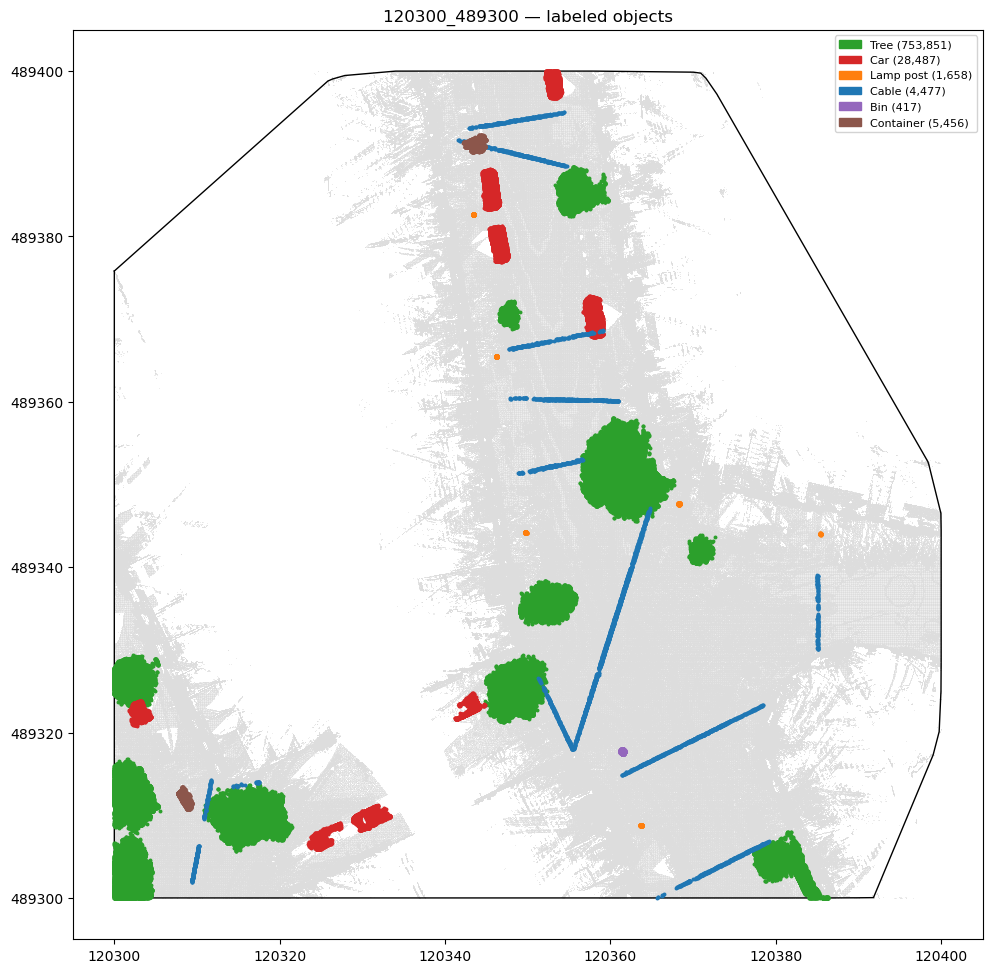


120300_488900
  Unknown            (label  0):  4,225,708
  Road               (label  1):    278,204
  Ground             (label  9):  1,055,947
  Tree               (label 30):  4,568,818
  Lamp post          (label 60):      1,748
  Cable              (label 79):        413


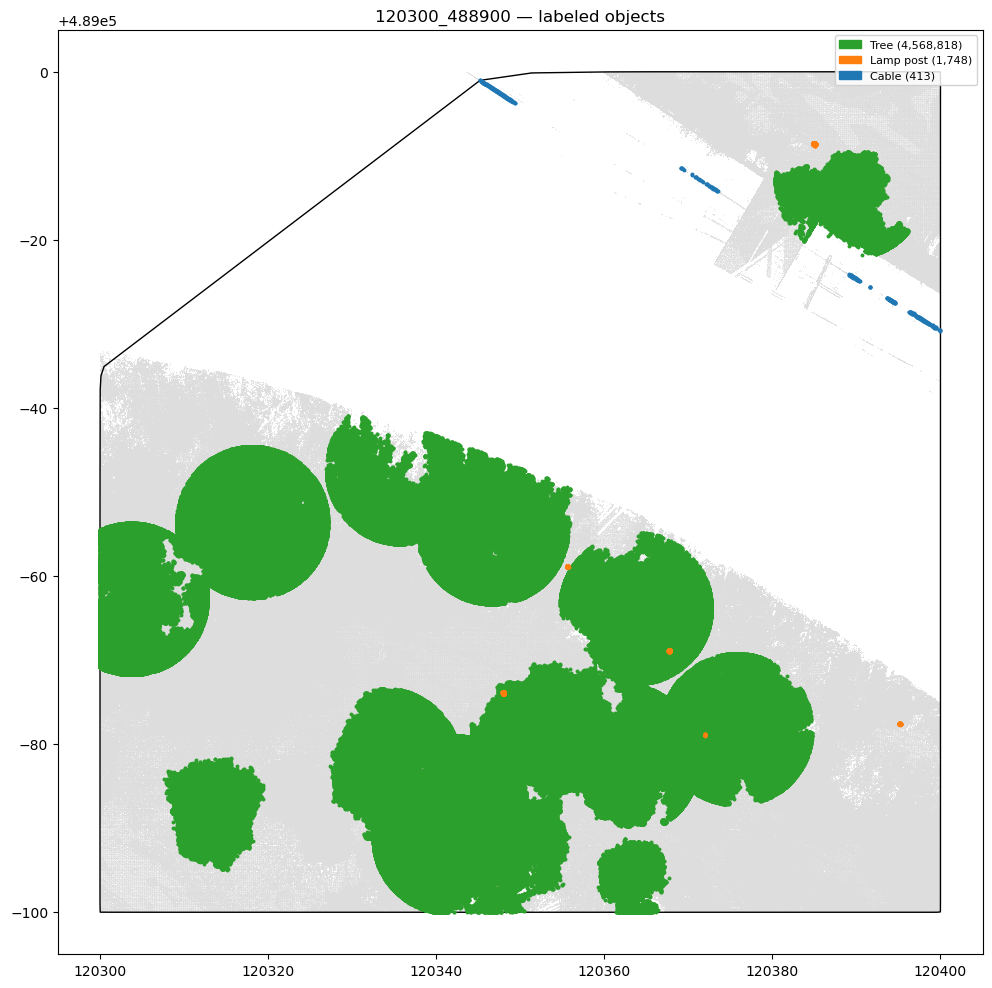


120700_489300
  Unknown            (label  0):    834,153
  Road               (label  1):    935,567
  Ground             (label  9):    674,881
  Building           (label 10):    505,007
  Tree               (label 30):  2,111,126
  Lamp post          (label 60):      5,110
  Cable              (label 79):        370


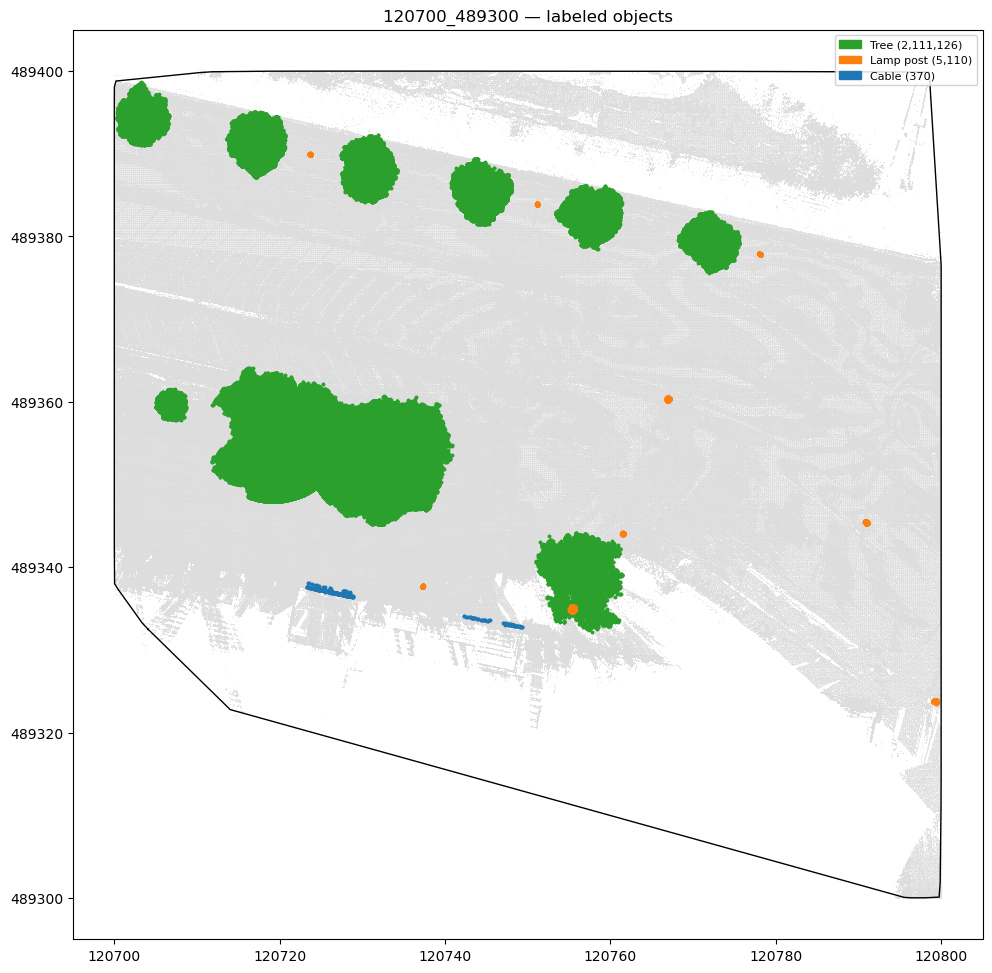


119900_489300
  Unknown            (label  0):  3,071,265
  Road               (label  1):    254,291
  Ground             (label  9):    311,040
  Building           (label 10):  1,311,626
  Car                (label 40):     42,832
  Lamp post          (label 60):      1,779
  Cable              (label 79):        849
  Container          (label 83):      3,004
  Armatuur           (label 90):        204


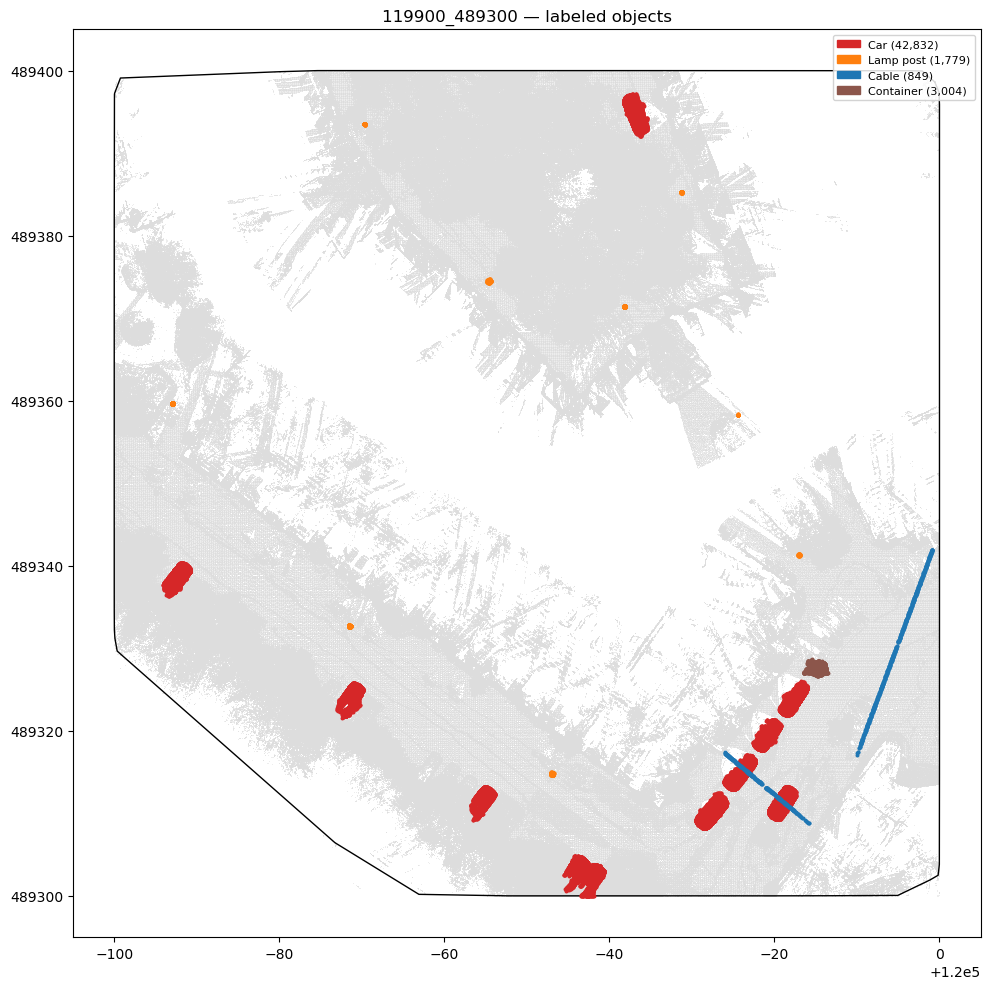


120300_489700
  Unknown            (label  0):    606,541
  Road               (label  1):    126,844
  Ground             (label  9):    141,151
  Building           (label 10):  1,086,480
  Tree               (label 30):    511,778
  Car                (label 40):     22,572
  Lamp post          (label 60):      2,116
  Cable              (label 79):        156
  Bin                (label 81):        245


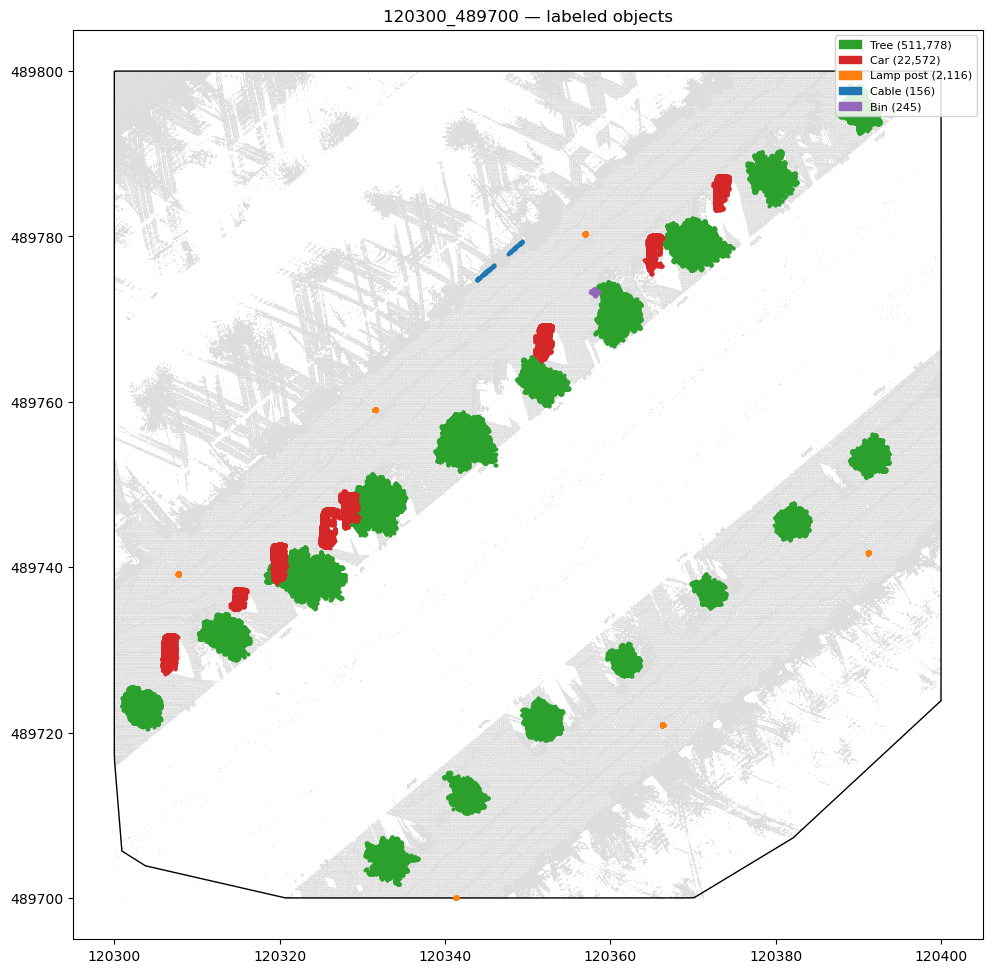


121100_484900


FileNotFoundError: [Errno 2] No such file or directory: 'data/output/labeled_pointcloud/bgt_labeled_121100_484900.laz'

In [8]:
try:
    import datashader as ds
    import datashader.transfer_functions as tf
    import pandas as pd
    HAS_DATASHADER = True
except ImportError:
    HAS_DATASHADER = False
    print("datashader not found — falling back to matplotlib")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OBJECT_LABEL_IDS = [30, 40, 60, 61, 62, 70, 79, 80, 81, 83, 85, 88, 89, 91]

for tilecode in tilecodes:
    print(f"\n{tilecode}")
    x, y, lbl = load_tile(tilecode)
    rings = load_tile_ring(tilecode)

    unique, counts = np.unique(lbl, return_counts=True)
    for u, c in zip(unique, counts):
        name = LABEL_NAMES.get(int(u), str(u))
        print(f"  {name:<18} (label {int(u):>2}): {c:>10,}")

    fig, ax = plt.subplots(figsize=(10, 10))
    obj_mask = np.isin(lbl, OBJECT_LABEL_IDS)
    ax.scatter(x[~obj_mask], y[~obj_mask], c='#dddddd', s=0.2,
               linewidths=0, rasterized=True, zorder=1)
    for ring_xs, ring_ys in rings:
        ax.plot(ring_xs, ring_ys, 'k-', linewidth=1, zorder=2)
    handles = []
    for lbl_id in OBJECT_LABEL_IDS:
        m = lbl == lbl_id
        if not m.any(): continue
        color = LABEL_COLORS.get(lbl_id, '#aaaaaa')
        name  = LABEL_NAMES.get(lbl_id, str(lbl_id))
        ax.scatter(x[m], y[m], c=color, s=8, linewidths=0, zorder=3)
        handles.append(mpatches.Patch(color=color, label=f'{name} ({m.sum():,})'))
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.85)
    ax.set_aspect('equal')
    ax.set_title(f'{tilecode} — labeled objects')
    plt.tight_layout()
    plt.show()


In [ ]:
from scipy.spatial import cKDTree
import matplotlib.lines as mlines

# (name, reader, bgt_types or None, label_id, max_dist)
MISSING_SOURCES = [
    ("Tree",          bomen_reader,     None,                             Labels.TREE,            2.0),
    ("Lamp post",     poles_reader,     ["lichtmast"],                    Labels.STREET_LIGHT,    1.5),
    ("Traffic light", poles_reader,     ["verkeersregelinstallatiepaal"],  Labels.TRAFFIC_LIGHT,   1.5),
    ("Traffic sign",  poles_reader,     ["verkeersbordpaal"],              Labels.TRAFFIC_SIGN,    1.5),
    ("Container",     furniture_reader, ["afval apart plaats"],            Labels.LARGE_CONTAINER, 3.0),
    ("Bench",         furniture_reader, ["bank"],                          Labels.CITY_BENCH,      1.0),
    ("Bin",           oor_afval_reader, None,                             Labels.RUBBISH_BIN,     1.0),
    ("Bike rack",     furniture_reader, ["fietsenrek"],                    Labels.BICYCLE_RACK,    1.5),
    ("Terrace",       terras_reader,    None,                             Labels.TERRACE,         2.0),
]

for tilecode in tilecodes:
    x, y, lbl = load_tile(tilecode)
    rings = load_tile_ring(tilecode)

    all_ring_xs = [xi for ring_xs, _ in rings for xi in ring_xs]
    all_ring_ys = [yi for _, ring_ys in rings for yi in ring_ys]
    tx0, tx1 = min(all_ring_xs), max(all_ring_xs)
    ty0, ty1 = min(all_ring_ys), max(all_ring_ys)

    fig, ax = plt.subplots(figsize=(10, 10))
    obj_mask = np.isin(lbl, OBJECT_LABEL_IDS)
    ax.scatter(x[~obj_mask], y[~obj_mask], c='#dddddd', s=0.2,
               linewidths=0, rasterized=True, zorder=1)
    for ring_xs, ring_ys in rings:
        ax.plot(ring_xs, ring_ys, 'k-', linewidth=1, zorder=2)

    handles = []

    for lbl_id in OBJECT_LABEL_IDS:
        m = lbl == lbl_id
        if not m.any():
            continue
        color = LABEL_COLORS.get(lbl_id, '#aaaaaa')
        name  = LABEL_NAMES.get(lbl_id, str(lbl_id))
        ax.scatter(x[m], y[m], c=color, s=8, linewidths=0, zorder=3)
        handles.append(mpatches.Patch(color=color, label=f'{name} ({m.sum():,})'))

    for obj_name, reader, bgt_types, label_id, max_dist in MISSING_SOURCES:
        lbl_int = int(label_id)
        color = LABEL_COLORS.get(lbl_int, '#aaaaaa')

        if bgt_types is not None:
            bgt_pts = reader.filter_tile(tilecode, bgt_types=bgt_types, padding=0)
        else:
            bgt_pts = reader.filter_tile(tilecode, padding=0)

        if not bgt_pts:
            continue

        bgt_xy = np.array(bgt_pts, dtype=float)
        in_tile = (
            (bgt_xy[:, 0] >= tx0) & (bgt_xy[:, 0] <= tx1) &
            (bgt_xy[:, 1] >= ty0) & (bgt_xy[:, 1] <= ty1)
        )
        bgt_xy = bgt_xy[in_tile]
        if len(bgt_xy) == 0:
            continue

        labeled_mask = lbl == lbl_int
        if labeled_mask.any():
            tree = cKDTree(np.column_stack([x[labeled_mask], y[labeled_mask]]))
            dists, _ = tree.query(bgt_xy, k=1)
            missing = bgt_xy[dists > max_dist]
        else:
            missing = bgt_xy

        if len(missing) == 0:
            continue

        ax.plot(missing[:, 0], missing[:, 1], '+',
                color=color, markersize=12, markeredgewidth=1.5, zorder=5)
        handles.append(mlines.Line2D([], [], color=color, marker='+', markersize=10,
                                     linewidth=0, label=f'Missing {obj_name} ({len(missing)})'))

    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.85)
    ax.set_aspect('equal')
    ax.set_title(f'{tilecode} — missing BGT objects (+ = expected but not labeled)')
    plt.tight_layout()
    plt.show()


In [ ]:
import json
from shapely.geometry import shape, Point
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import cKDTree
import matplotlib.lines as mlines

CAR_LABEL = int(Labels.CAR)
CAR_COLOR = LABEL_COLORS.get(CAR_LABEL, '#aaaaaa')

for tilecode in tilecodes:
    x, y, lbl = load_tile(tilecode)
    rings = load_tile_ring(tilecode)

    all_ring_xs = [xi for ring_xs, _ in rings for xi in ring_xs]
    all_ring_ys = [yi for _, ring_ys in rings for yi in ring_ys]
    tx0, tx1 = min(all_ring_xs), max(all_ring_xs)
    ty0, ty1 = min(all_ring_ys), max(all_ring_ys)

    obs_file = OBSTACLES_DIR / f"obstacles_labeled_{tilecode}.geojson"
    obstacles = []
    if obs_file.exists():
        with open(obs_file) as f:
            fc = json.load(f)
        obstacles = [shape(feat["geometry"]) for feat in fc["features"]]

    # Collect per-source BGT locations once; reuse for obstacles and markers
    source_data = []  # (obj_name, bgt_xy, lbl_int, max_dist, color)
    for obj_name, reader, bgt_types, label_id, max_dist in MISSING_SOURCES:
        lbl_int = int(label_id)
        color = LABEL_COLORS.get(lbl_int, '#aaaaaa')
        pts = (reader.filter_tile(tilecode, bgt_types=bgt_types, padding=0)
               if bgt_types is not None
               else reader.filter_tile(tilecode, padding=0))
        if not pts:
            continue
        bgt_xy = np.array(pts, dtype=float)
        in_tile = ((bgt_xy[:, 0] >= tx0) & (bgt_xy[:, 0] <= tx1) &
                   (bgt_xy[:, 1] >= ty0) & (bgt_xy[:, 1] <= ty1))
        bgt_xy = bgt_xy[in_tile]
        if len(bgt_xy):
            source_data.append((obj_name, bgt_xy, lbl_int, max_dist, color))

    # Cars: check each parking spot for labeled car points
    car_mask = lbl == CAR_LABEL
    car_found, car_missing = [], []
    for poly in parking_reader.filter_tile(tilecode, padding=0):
        cx, cy = poly.centroid.x, poly.centroid.y
        if not (tx0 <= cx <= tx1 and ty0 <= cy <= ty1):
            continue
        minx, miny, maxx, maxy = poly.bounds
        in_bbox = car_mask & (x >= minx) & (x <= maxx) & (y >= miny) & (y <= maxy)
        hit = any(poly.contains(Point(float(px), float(py)))
                  for px, py in zip(x[in_bbox], y[in_bbox]))
        (car_found if hit else car_missing).append((cx, cy))

    car_found_xy   = np.array(car_found,   dtype=float) if car_found   else np.empty((0, 2))
    car_missing_xy = np.array(car_missing, dtype=float) if car_missing else np.empty((0, 2))

    # All BGT source points (point sources + parking centroids) for obstacle coloring
    all_bgt_parts = [d[1] for d in source_data]
    if len(car_found_xy):   all_bgt_parts.append(car_found_xy)
    if len(car_missing_xy): all_bgt_parts.append(car_missing_xy)
    all_bgt_xy = np.vstack(all_bgt_parts) if all_bgt_parts else np.empty((0, 2))

    # Determine which obstacles contain at least one BGT source point
    obs_has_bgt = []
    for poly in obstacles:
        minx, miny, maxx, maxy = poly.bounds
        hit = any(
            minx <= px <= maxx and miny <= py <= maxy and poly.contains(Point(px, py))
            for px, py in all_bgt_xy
        )
        obs_has_bgt.append(hit)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.scatter(x, y, c='#dddddd', s=0.2, linewidths=0, rasterized=True, zorder=1)
    for ring_xs, ring_ys in rings:
        ax.plot(ring_xs, ring_ys, 'k-', linewidth=1, zorder=2)

    handles = []

    # Obstacle outlines: red if a BGT source is inside, gray otherwise
    for poly, has_bgt in zip(obstacles, obs_has_bgt):
        coords = np.array(poly.exterior.coords)
        ax.add_patch(MplPolygon(coords, closed=True, facecolor='none',
                                edgecolor='#cc0000' if has_bgt else '#999999',
                                linewidth=0.8, zorder=2))

    # Stars (found) and crosses (missing) at BGT point-source locations
    for obj_name, bgt_xy, lbl_int, max_dist, color in source_data:
        labeled_mask = lbl == lbl_int
        if labeled_mask.any():
            tree = cKDTree(np.column_stack([x[labeled_mask], y[labeled_mask]]))
            dists, _ = tree.query(bgt_xy, k=1)
            found   = bgt_xy[dists <= max_dist]
            missing = bgt_xy[dists >  max_dist]
        else:
            found   = np.empty((0, 2))
            missing = bgt_xy

        if len(found):
            ax.plot(found[:, 0], found[:, 1], '*', color=color, markersize=12,
                    markeredgecolor='black', markeredgewidth=0.5, zorder=5)
            handles.append(mlines.Line2D([], [], color=color, marker='*', markersize=10,
                                         markeredgecolor='black', markeredgewidth=0.5,
                                         linewidth=0, label=f'{obj_name} found ({len(found)})'))
        if len(missing):
            ax.plot(missing[:, 0], missing[:, 1], '+', color=color,
                    markersize=12, markeredgewidth=1.5, zorder=5)
            handles.append(mlines.Line2D([], [], color=color, marker='+', markersize=10,
                                         linewidth=0, label=f'{obj_name} missing ({len(missing)})'))

    # Stars and crosses for cars (parking spot centroids)
    if len(car_found_xy):
        ax.plot(car_found_xy[:, 0], car_found_xy[:, 1], '*', color=CAR_COLOR,
                markersize=12, markeredgecolor='black', markeredgewidth=0.5, zorder=5)
        handles.append(mlines.Line2D([], [], color=CAR_COLOR, marker='*', markersize=10,
                                     markeredgecolor='black', markeredgewidth=0.5,
                                     linewidth=0, label=f'Car found ({len(car_found_xy)})'))
    if len(car_missing_xy):
        ax.plot(car_missing_xy[:, 0], car_missing_xy[:, 1], '+', color=CAR_COLOR,
                markersize=12, markeredgewidth=1.5, zorder=5)
        handles.append(mlines.Line2D([], [], color=CAR_COLOR, marker='+', markersize=10,
                                     linewidth=0, label=f'Car missing ({len(car_missing_xy)})'))

    n_red  = sum(obs_has_bgt)
    n_gray = len(obstacles) - n_red
    if n_red:
        handles.append(mpatches.Patch(facecolor='none', edgecolor='#cc0000',
                                      linewidth=0.8, label=f'obstacle w/ BGT source ({n_red})'))
    if n_gray:
        handles.append(mpatches.Patch(facecolor='none', edgecolor='#999999',
                                      linewidth=0.8, label=f'obstacle w/o BGT source ({n_gray})'))

    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.85)
    ax.set_aspect('equal')
    ax.set_title(f'{tilecode} — BGT sources vs labels  (★ = found,  + = missing)')
    plt.tight_layout()
    plt.show()
